In [74]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "emnist/letters",
    as_supervised=True,
    with_info=True
)

In [76]:
train_data = dataset['train']
test_data = dataset['test']

In [77]:
import tensorflow as tf

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0

    # FIX orientation (VERY IMPORTANT)
    image = tf.image.rot90(image, k=3)
    image = tf.image.flip_left_right(image)

    # convert 1–26 → 0–25
    label = label - 1

    return image, label

In [78]:
train_data = train_data.map(preprocess).batch(64)
test_data = test_data.map(preprocess).batch(64)

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

emnist_model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(26, activation='softmax')   # 26 letters
])

In [80]:
emnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
history_emnist = emnist_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.7455 - loss: 0.8310 - val_accuracy: 0.8822 - val_loss: 0.3648
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8601 - loss: 0.4453 - val_accuracy: 0.9011 - val_loss: 0.2886
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.8833 - loss: 0.3653 - val_accuracy: 0.9136 - val_loss: 0.2575
Epoch 4/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.8980 - loss: 0.3182 - val_accuracy: 0.9158 - val_loss: 0.2467
Epoch 5/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.9062 - loss: 0.2865 - val_accuracy: 0.9190 - val_loss: 0.2360


In [85]:
import numpy as np

X_test = np.concatenate([x.numpy() for x, y in test_data], axis=0)
y_test = np.concatenate([y.numpy() for x, y in test_data], axis=0)

In [86]:
y_pred = emnist_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

463/463 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


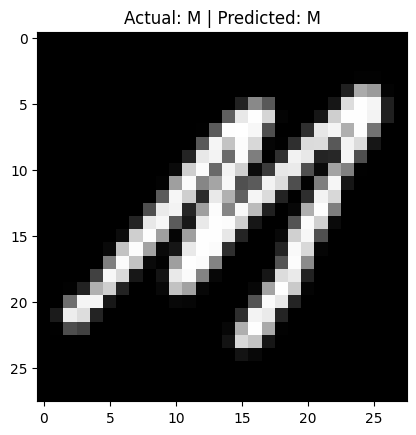

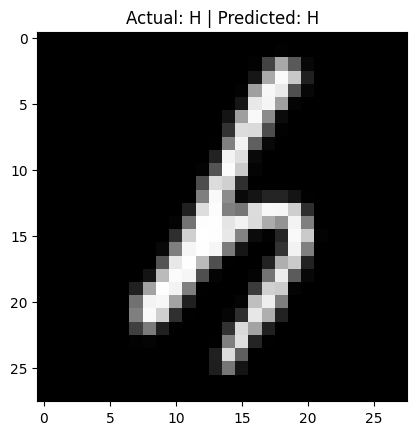

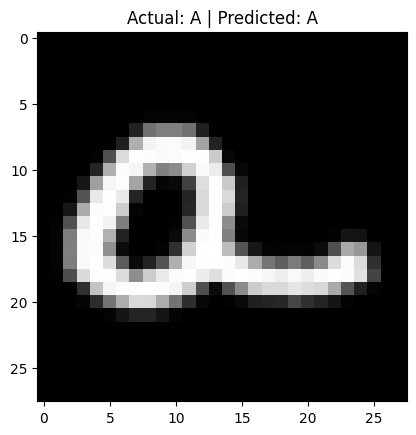

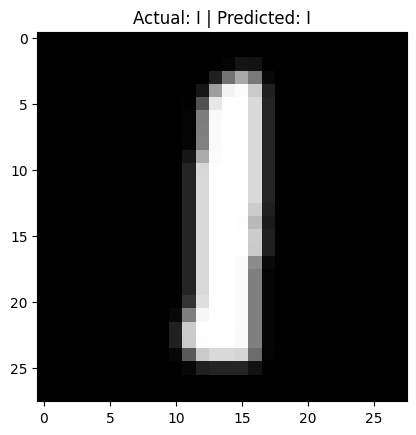

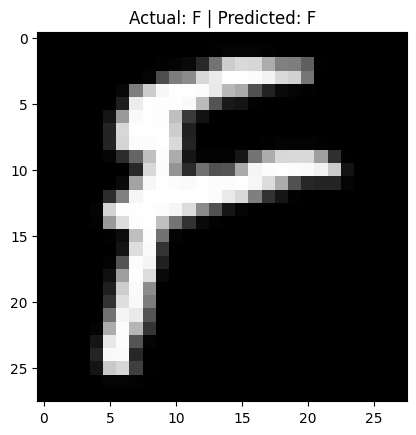

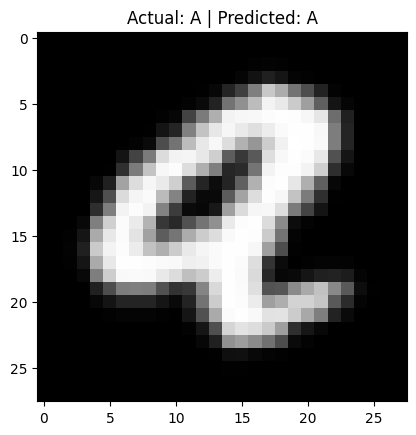

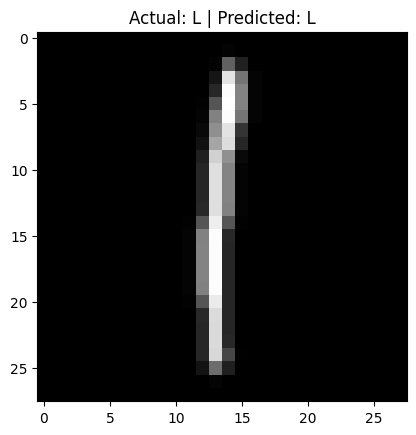

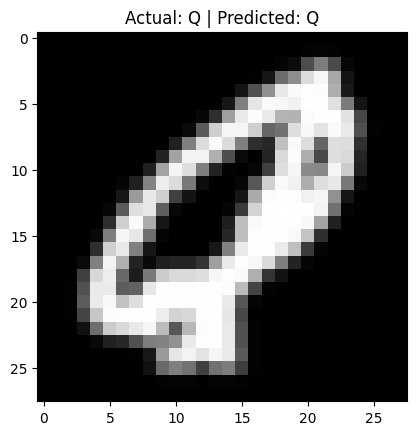

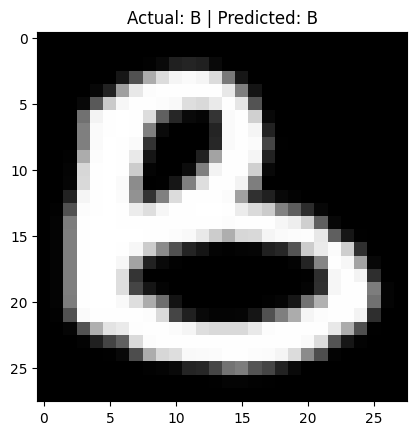

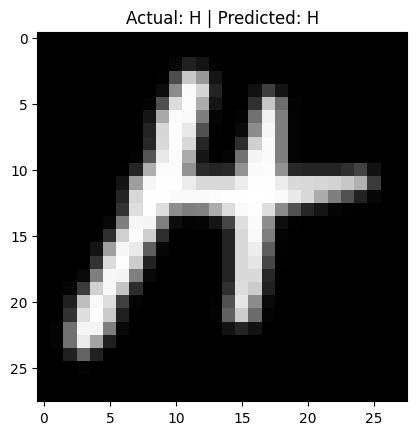

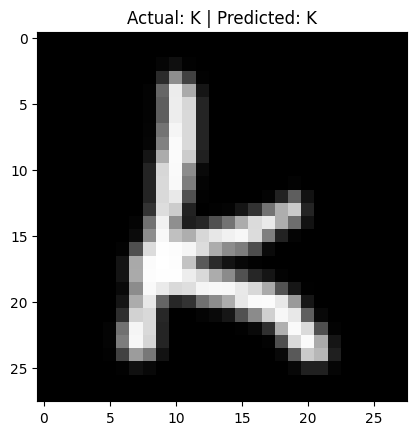

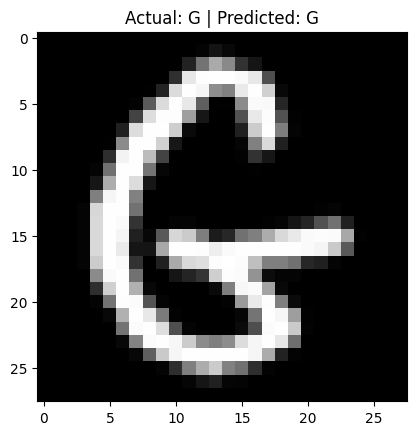

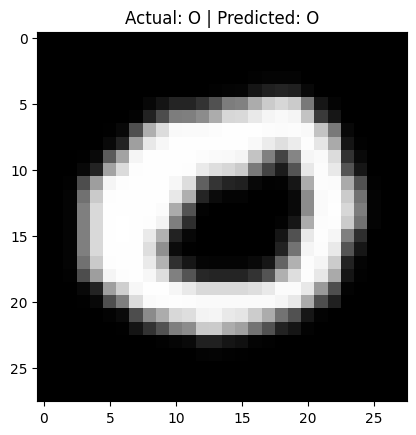

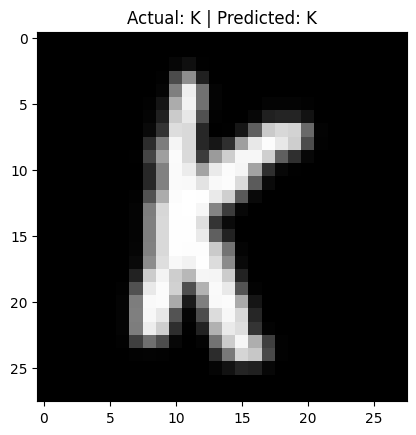

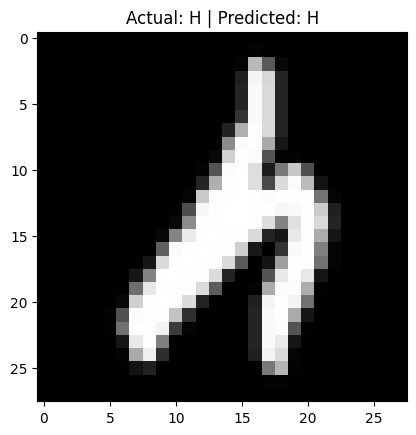

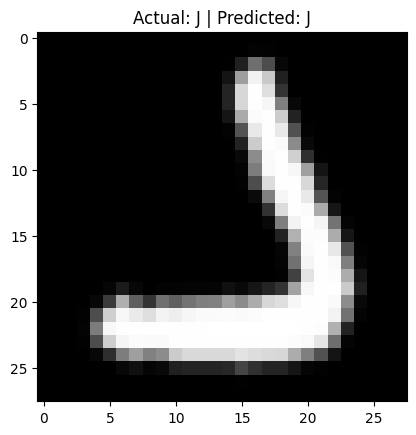

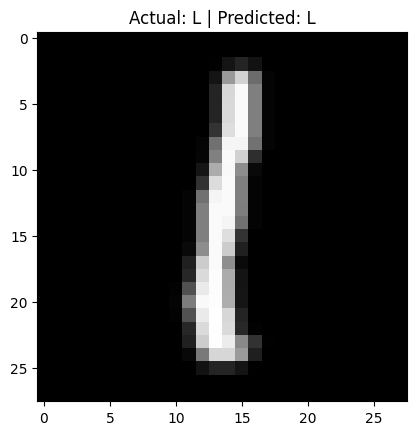

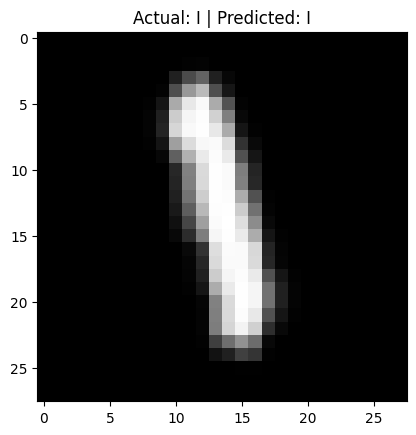

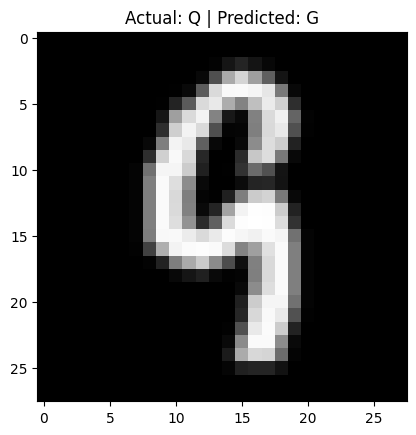

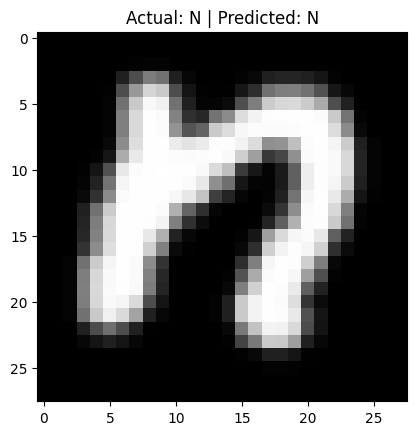

In [88]:
import matplotlib.pyplot as plt
import string

label_names = list(string.ascii_uppercase)

for i in range(20):

    img = X_test[i].reshape(28,28)

    actual = label_names[int(y_test[i])]
    predicted = label_names[int(y_pred_classes[i])]

    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.show()

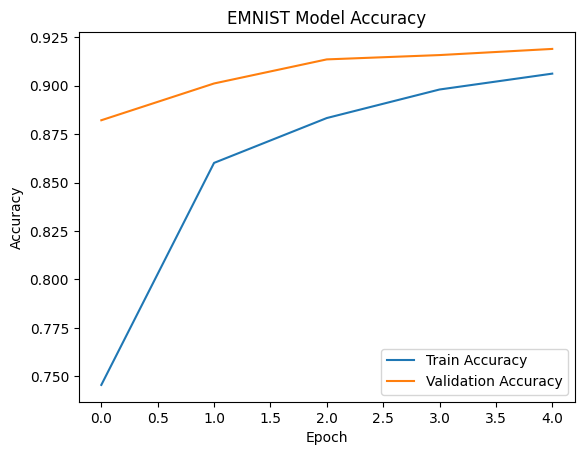

In [89]:
import matplotlib.pyplot as plt

plt.plot(history_emnist.history['accuracy'], label='Train Accuracy')
plt.plot(history_emnist.history['val_accuracy'], label='Validation Accuracy')

plt.title("EMNIST Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

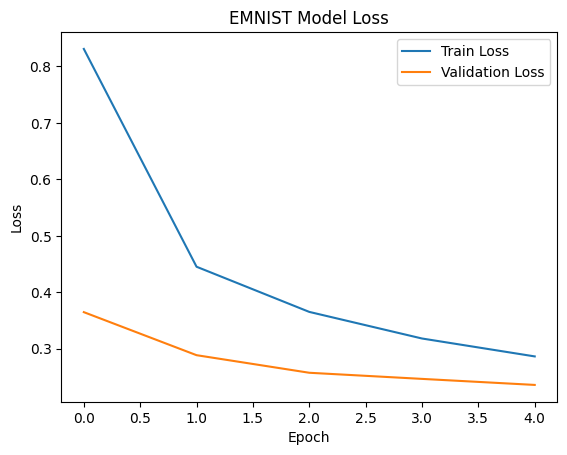

In [90]:
plt.plot(history_emnist.history['loss'], label='Train Loss')
plt.plot(history_emnist.history['val_loss'], label='Validation Loss')

plt.title("EMNIST Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [91]:
emnist_model.save("emnist_model.keras")